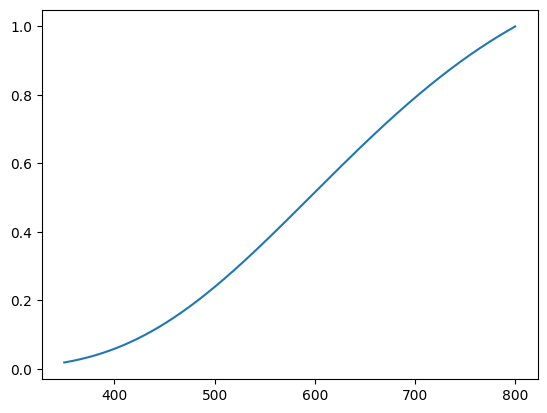

In [26]:
"""spectral analysis(colormaster alpha 1.0)"""
"""By Matija Breljak"""
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from colorist import ColorRGB

Pipeline=[]
LightSource=[]
FilmList=pd.read_csv("Film-List.csv")
ElementList=pd.read_csv("Element_List.csv")
SmpList=pd.read_csv("Sample-List.csv")
method=0 #default is 0 for averaging exposure(other values will be added for median, log and other possible methods)
##defs
def PdtoA(PDin, x):
  return np.array(PDin.iloc[:, x])
def IntegrateChannel(Channel):
  z=0
  x, y = PdtoA(Channel, 0), PdtoA(Channel, 1)
  for i in range(len(x)-1):
    if np.isnan(y[i]) or np.isnan(y[i+1]):
      continue
    else:
      z+=(x[i+1]-x[i])*(y[i]+y[i+1])/2
  return z
def CalculateColorRGB(InSp3, InSp3W):
  xc, yc, xm, ym, xy, yy = PdtoA(InSp3, 0), PdtoA(InSp3, 1), PdtoA(InSp3, 2), PdtoA(InSp3, 3), PdtoA(InSp3, 4), PdtoA(InSp3, 5)
  wxc, wyc, wxm, wym, wxy, wyy = PdtoA(InSp3W, 0), PdtoA(InSp3W, 1), PdtoA(InSp3W, 2), PdtoA(InSp3W, 3), PdtoA(InSp3W, 4), PdtoA(InSp3W, 5)
  C = pd.DataFrame({ "x": xc, "y": yc})
  M = pd.DataFrame({ "x": xm, "y": ym})
  Y = pd.DataFrame({ "x": xy, "y": yy})
  CW = pd.DataFrame({ "x": wxc, "y": wyc})
  MW = pd.DataFrame({ "x": wxm, "y": wym})
  YW = pd.DataFrame({ "x": wxy, "y": wyy})
  R = IntegrateChannel(C)
  G = IntegrateChannel(M)
  B = IntegrateChannel(Y)
  W = max(IntegrateChannel(CW),IntegrateChannel(MW),IntegrateChannel(YW))
  return ColorRGB(int(255*R/W),int(255*G/W),int(255*B/W))
def CalculateExposureLoss(sp1,sp2):
  RLoss=np.log2(IntegrateChannel(pd.DataFrame({"x":PdtoA(sp1,0),"y":PdtoA(sp1,1)}))/(0.0001+IntegrateChannel(pd.DataFrame({"x":PdtoA(sp2,0),"y":PdtoA(sp2,1)}))))
  GLoss=np.log2(IntegrateChannel(pd.DataFrame({"x":PdtoA(sp1,2),"y":PdtoA(sp1,3)}))/(0.0001+IntegrateChannel(pd.DataFrame({"x":PdtoA(sp2,2),"y":PdtoA(sp2,3)}))))
  BLoss=np.log2(IntegrateChannel(pd.DataFrame({"x":PdtoA(sp1,4),"y":PdtoA(sp1,5)}))/(0.0001+IntegrateChannel(pd.DataFrame({"x":PdtoA(sp2,4),"y":PdtoA(sp2,5)}))))
  return ("R", RLoss, "G", GLoss, "B", BLoss, "Avg", np.average([RLoss, GLoss, BLoss]))
def ApplyFilter(InSp,Element):
  x_coords, y_coords = PdtoA(InSp, 0) , PdtoA(InSp, 1)
  filter_x, filter_y = PdtoA(Element, 0), PdtoA(Element, 1)
  interpolated_filter = np.interp(x_coords, filter_x, filter_y)
  return pd.DataFrame({"x": x_coords.tolist(), "y": (y_coords * interpolated_filter).tolist()})
def ApplyPipeline(InSp,Pipeline):
  for i in range(len(Pipeline)):
    InSp=ApplyFilter(InSp,Pipeline[i])
  return InSp
def FilterFilm(InSp3, Pipeline):
  xc, yc, xm, ym, xy, yy = PdtoA(InSp3, 0), PdtoA(InSp3, 1), PdtoA(InSp3, 2), PdtoA(InSp3, 3), PdtoA(InSp3, 4), PdtoA(InSp3, 5)
  C = pd.DataFrame({ "x": xc, "y": yc})
  M = pd.DataFrame({ "x": xm, "y": ym})
  Y = pd.DataFrame({ "x": xy, "y": yy})
  R = ApplyPipeline(C, Pipeline)
  G = ApplyPipeline(M, Pipeline)
  B = ApplyPipeline(Y, Pipeline)
  return pack(R, G, B)
def pack(InSp1, InSp2, InSp3):
  xc, yc, xm, ym, xy, yy = PdtoA(InSp1, 0), PdtoA(InSp1, 1), PdtoA(InSp2, 0), PdtoA(InSp2, 1), PdtoA(InSp3, 0), PdtoA(InSp3, 1)
  return pd.DataFrame({ "xc": xc, "yc": yc, "xm": xm, "ym": ym, "xy": xy, "yy":yy})
def CorrectSpectrumAVG(InSp3):
  xc, yc, xm, ym, xy, yy = PdtoA(InSp3, 0), PdtoA(InSp3, 1), PdtoA(InSp3, 2), PdtoA(InSp3, 3), PdtoA(InSp3, 4), PdtoA(InSp3, 5)
  C = pd.DataFrame({ "x": xc, "y": yc})
  M = pd.DataFrame({ "x": xm, "y": ym})
  Y = pd.DataFrame({ "x": xy, "y": yy})
  R = IntegrateChannel(C)
  G = IntegrateChannel(M)
  B = IntegrateChannel(Y)
  T = np.average([R, G, B])
  C = pd.DataFrame({"x": xc, "y": yc*T/R})
  M = pd.DataFrame({"x": xm, "y": ym*T/G})
  Y = pd.DataFrame({"x": xy, "y": yy*T/B})
  return pack(C, M, Y)
def ApplySampleSP(InSp3, SampleSP):
  xc, yc, xm, ym, xy, yy = PdtoA(InSp3, 0), PdtoA(InSp3, 1), PdtoA(InSp3, 2), PdtoA(InSp3, 3), PdtoA(InSp3, 4), PdtoA(InSp3, 5)
  C = pd.DataFrame({ "x": xc, "y": yc})
  M = pd.DataFrame({ "x": xm, "y": ym})
  Y = pd.DataFrame({ "x": xy, "y": yy})
  R = ApplyFilter(C,SampleSP)
  G = ApplyFilter(M,SampleSP)
  B = ApplyFilter(Y,SampleSP)
  return pack(R, G, B)
def GenerateLightSource(T):
  x = np.arange(350, 801, 1)
  y = 1/((x**5)*np.expm1(1.4388e7/(x*T)))
  y = y/np.max(y)
  return pd.DataFrame({"x": x, "y": y})
##Run
Light = GenerateLightSource(2856)
plt.plot(Light.x, Light.y)

def InputReportToTextFile(Pipeline):
  with open("InputReport.txt", "w") as f:
    f.write("Pipeline:\n")
    for i, element in enumerate(Pipeline):
      f.write(f"Element {i+1}:\n")
      f.write(element.to_string(index=False))
      f.write("\n\n")


In [ ]:
print("choose film")
print(FilmList)
Film=pd.read_csv(str(FilmList.iloc[int(input("Film number: "))-1,1]))
xc, yc, xm, ym, xy, yy = PdtoA(Film, 0), PdtoA(Film, 1), PdtoA(Film, 2), PdtoA(Film, 3), PdtoA(Film, 4), PdtoA(Film, 5)
yc, ym, yy = 10**(yc), 10**(ym), 10**(yy)
Film = pd.DataFrame({"xc": xc, "yc": yc, "xm": xm, "ym": ym, "xy": xy, "yy": yy})
e=0

while(e!=-2):
  print("choose filters/elements (enter -1 if you finnished with adding filters)")
  print(ElementList.iloc[0,1:])
  e=int(input("Filter number: "))-1
  Pipeline.append(pd.read_csv(str(ElementList.iloc[e,1])))
print("choose test sample")
print(SmpList)
TestSmp=pd.read_csv(str(SmpList.iloc[int(input("Test sample number: "))-1,1]))
print("only white correction method avaliable is average")
T = input("Set light source temperature in kelvins (default is 2856K): ")
if T == "":
  T = 2856
else:
  T = float(T)
Light = GenerateLightSource(T)
Pipeline.append(Light)




choose film
   x                          y
0  1  Kodak-Portra-800-data.csv
choose filters/elements (enter -1 if you finnished with adding filters)
x                 1
y    KB-12-data.csv
Name: 0, dtype: object


In [ ]:
InputReportToTextFile(Pipeline)


plotting spectra
true film spectrum


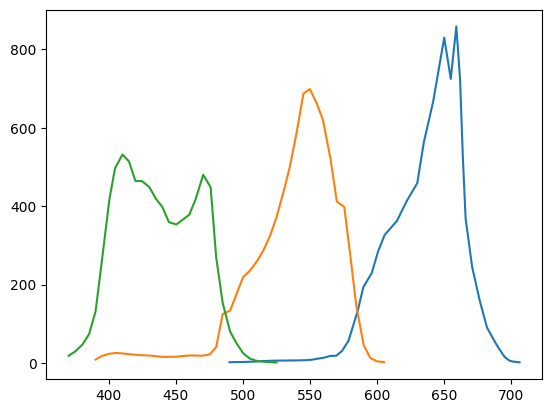

true film spectrum + filters


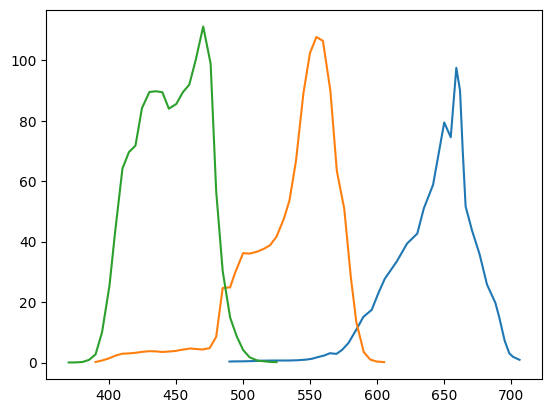

compiled film spectrum + filters


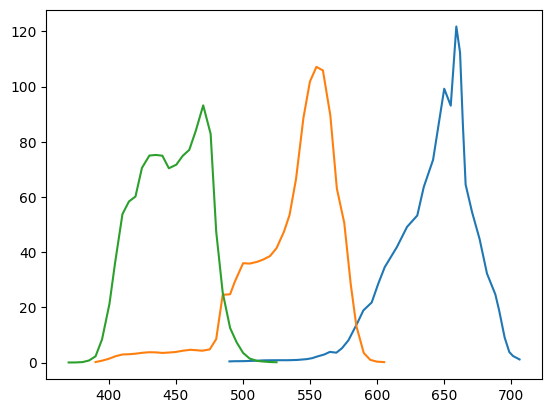

compiled film spectrum + filters + sample


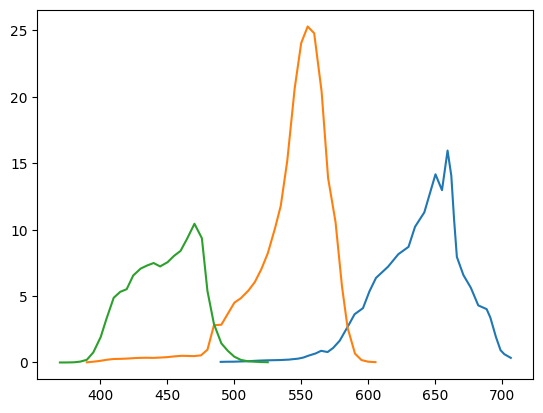

COLOR ANALYSIS:
true white of the film ▉
true white + filters ▉
true sample color ▉
true sample color + filters ▉
post correction sample ▉
post correction sample + filters ▉
true exposure loss  ('R', np.float64(3.2058783346573256), 'G', np.float64(2.82241413818134), 'B', np.float64(2.5107800993569596), 'Avg', np.float64(2.8463575240652084))


In [25]:
WTrue = CalculateColorRGB(Film,Film)
WTrueF = CalculateColorRGB(FilterFilm(Film,Pipeline),FilterFilm(Film,Pipeline))
STrue = CalculateColorRGB(ApplySampleSP(Film, TestSmp),Film)
STrueF = CalculateColorRGB(ApplySampleSP(FilterFilm(Film, Pipeline), TestSmp),Film)
SPost = CalculateColorRGB(ApplySampleSP(CorrectSpectrumAVG(Film), TestSmp),CorrectSpectrumAVG(Film))
SPostF = CalculateColorRGB(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp),CorrectSpectrumAVG(FilterFilm(Film, Pipeline)))
ELossT = CalculateExposureLoss(Film, FilterFilm(Film, Pipeline))

print("plotting spectra")
print("true film spectrum")
plt.plot(PdtoA(Film, 0), PdtoA(Film, 1), label="FilmR")
plt.plot(PdtoA(Film, 2), PdtoA(Film, 3), label="FilmG")
plt.plot(PdtoA(Film, 4), PdtoA(Film, 5), label="FilmB")
plt.show()
print("true film spectrum + filters")
plt.plot(PdtoA(FilterFilm(Film,Pipeline), 0), PdtoA(FilterFilm(Film,Pipeline), 1), label="FilmR")
plt.plot(PdtoA(FilterFilm(Film,Pipeline), 2), PdtoA(FilterFilm(Film,Pipeline), 3), label="FilmG")
plt.plot(PdtoA(FilterFilm(Film,Pipeline), 4), PdtoA(FilterFilm(Film,Pipeline), 5), label="FilmB")
plt.show()
print("compiled film spectrum + filters")
plt.plot(PdtoA(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), 0), PdtoA(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), 1), label="FilmR")
plt.plot(PdtoA(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), 2), PdtoA(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), 3), label="FilmG")
plt.plot(PdtoA(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), 4), PdtoA(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), 5), label="FilmB")
plt.show()
print("compiled film spectrum + filters + sample")
plt.plot(PdtoA(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp), 0), PdtoA(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp), 1), label="FilmR")
plt.plot(PdtoA(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp), 2), PdtoA(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp), 3), label="FilmG")
plt.plot(PdtoA(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp), 4), PdtoA(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp), 5), label="FilmB")
plt.show()


print("COLOR ANALYSIS:")
print(f"true white of the film {WTrue}▉{ColorRGB.OFF}")
print(f"true white + filters {WTrueF}▉{ColorRGB.OFF}")
print(f"true sample color {STrue}▉{ColorRGB.OFF}")
print(f"true sample color + filters {STrueF}▉{ColorRGB.OFF}")
print(f"post correction sample {SPost}▉{ColorRGB.OFF}")
print(f"post correction sample + filters {SPostF}▉{ColorRGB.OFF}")
print("true exposure loss ",ELossT)